# Logistics Data Processing and Excel Automation with Python

## Project Overview
This project demonstrates how Python can automate the processing and analysis of logistics data stored in Excel files. The script cleans raw datasets, organizes the information, and generates summary reports to support operational decision-making.

## Objectives
- Automate the processing of Excel datasets
- Clean and standardize logistics data
- Generate summary reports
- Identify operational insights through data analysis

## Tools Used
- Python
- pandas
- openpyxl
- matplotlib
- Excel

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
file_path = "data/input.xlsx"

df = pd.read_excel(file_path)

print("Dataset Preview:")
print(df.head())

Dataset Preview:
  Sales Representative       Location Region         Customer  \
0          Sara Snyder  Massachusetts   East    Raymond Young   
1          Sara Snyder       New York   East       Helen Dean   
2       Diane Gonzalez     Washington   West   Shirley Chavez   
3          Sara Snyder     New Jersey   East       Brian Ryan   
4          Sara Snyder     New Jersey   East  Benjamin Willis   

            Order Date                                            Product  \
0  2016-01-01 00:00:00  Bravo II Megaboss 12-Amp Hard Body Upright, Re...   
1  2016-01-01 00:00:00  Hon Deluxe Fabric Upholstered Stacking Chairs,...   
2  2016-01-01 00:00:00  Acme Hot Forged Carbon Steel Scissors with Nic...   
3  2016-01-01 00:00:00      Bretford CR4500 Series Slim Rectangular Table   
4  2016-01-01 00:00:00                     Eldon Fold 'N Roll Cart System   

   Quantity  Price  Total Sale Amount  
0         6  12.42              74.52  
1         7  12.42              86.94  
2        

In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values
df = df.fillna("Unknown")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned Dataset:")
print(df.head())

Cleaned Dataset:
  sales_representative       location region         customer  \
0          Sara Snyder  Massachusetts   East    Raymond Young   
1          Sara Snyder       New York   East       Helen Dean   
2       Diane Gonzalez     Washington   West   Shirley Chavez   
3          Sara Snyder     New Jersey   East       Brian Ryan   
4          Sara Snyder     New Jersey   East  Benjamin Willis   

            order_date                                            product  \
0  2016-01-01 00:00:00  Bravo II Megaboss 12-Amp Hard Body Upright, Re...   
1  2016-01-01 00:00:00  Hon Deluxe Fabric Upholstered Stacking Chairs,...   
2  2016-01-01 00:00:00  Acme Hot Forged Carbon Steel Scissors with Nic...   
3  2016-01-01 00:00:00      Bretford CR4500 Series Slim Rectangular Table   
4  2016-01-01 00:00:00                     Eldon Fold 'N Roll Cart System   

   quantity  price  total_sale_amount  
0         6  12.42              74.52  
1         7  12.42              86.94  
2        

In [5]:
print("Dataset Info:")
print(df.info())

print("Summary Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5684 entries, 0 to 5683
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sales_representative  5684 non-null   object 
 1   location              5684 non-null   object 
 2   region                5684 non-null   object 
 3   customer              5684 non-null   object 
 4   order_date            5684 non-null   object 
 5   product               5684 non-null   object 
 6   quantity              5684 non-null   int64  
 7   price                 5684 non-null   float64
 8   total_sale_amount     5684 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 399.8+ KB
None
Summary Statistics:
          quantity        price  total_sale_amount
count  5684.000000  5684.000000        5684.000000
mean      5.521112    22.890009         126.631135
std       2.849021    16.004457         120.136622
min       1.000000    12.4

## Total Revenue Calculation

This section calculates the total revenue generated from all sales in the dataset.

In [7]:
# Total revenue
total_revenue = df["total_sale_amount"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 719771.3700000001


## Revenue Trend Over Time

This analysis evaluates how revenue changes over time based on order dates. 
Understanding sales trends over time can help logistics teams plan inventory,
shipping capacity, and operational resources.

In [20]:
df["order_date"] = pd.to_datetime(df["order_date"])

revenue_by_month = (
    df.groupby(df["order_date"].dt.to_period("M"))["total_sale_amount"]
    .sum()
    .reset_index()
)

print("Revenue by Month:")
print(revenue_by_month)

Revenue by Month:
   order_date  total_sale_amount
0     1970-01           27295.34
1     2016-01           52720.14
2     2016-02           48539.98
3     2016-03           54029.42
4     2016-04           57138.66
5     2016-05           51279.80
6     2016-06           58342.53
7     2016-07           58040.04
8     2016-08           45531.18
9     2016-09           48471.21
10    2016-10           51762.24
11    2016-11           47014.65
12    2016-12          119606.18


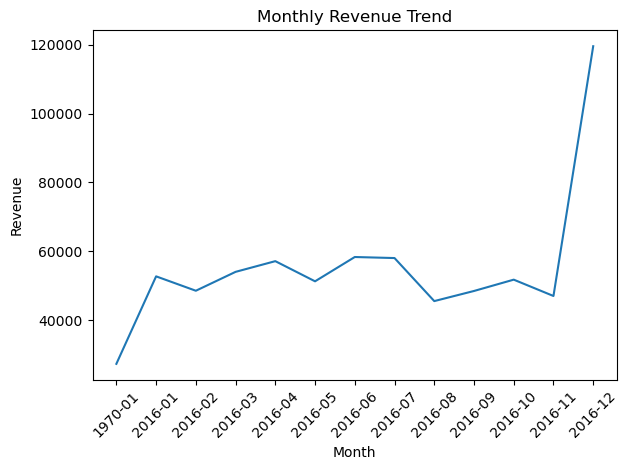

In [21]:
plt.figure()

plt.plot(
    revenue_by_month["order_date"].astype(str),
    revenue_by_month["total_sale_amount"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Revenue by Location

This analysis identifies which locations generate the highest revenue.

In [8]:
revenue_by_location = (
    df.groupby("location")["total_sale_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Revenue by Location:")
print(revenue_by_location)

Revenue by Location:
        location  total_sale_amount
0       New York          163954.30
1  Massachusetts          149602.34
2     Washington          100118.24
3     New Jersey           98518.38
4     California           79143.24
5         Oregon           69651.19
6    Connecticut           42043.25
7         Nevada           16740.43


## Orders by Region

This section analyzes how many orders are processed in each region.

In [9]:
orders_by_region = (
    df.groupby("region")
    .size()
    .reset_index(name="number_of_orders")
)

print("Orders by Region:")
print(orders_by_region)

Orders by Region:
    region  number_of_orders
0     East              3597
1  Unknown                 1
2     West              2086


## Revenue by Product

This analysis identifies which products generate the highest revenue.

In [10]:
revenue_by_product = (
    df.groupby("product")["total_sale_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Revenue by Product:")
print(revenue_by_product)

Revenue by Product:
                                                product  total_sale_amount
0                                               Unknown            6091.41
1                                       Staple envelope            4240.63
2                                     Easy-staple paper            3622.33
3                                               Staples            2588.03
4                               Avery Non-Stick Binders            2286.19
...                                                 ...                ...
1741                                         Newell 340              12.42
1742  Executive Impressions 14" Two-Color Numerals W...              12.42
1743  Canon Color ImageCLASS MF8580Cdw Wireless Lase...              12.42
1744  Standard Line “While You Were Out” Hardbound T...              12.42
1745             Panasonic Business Telephones KX-T7736              12.42

[1746 rows x 2 columns]


## Top Sales Representatives

This analysis identifies the sales representatives generating the highest revenue.

In [11]:
top_sales_reps = (
    df.groupby("sales_representative")["total_sale_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("Top Sales Representatives:")
print(top_sales_reps)

Top Sales Representatives:
  sales_representative  total_sale_amount
0          Sara Snyder          268212.07
1       Patrick Graham          167833.92
2         Randy Watson          113115.38
3       Diane Gonzalez           97819.18
4       Frances Warren           72790.82


## Revenue Visualization

This chart shows the revenue generated by each location.

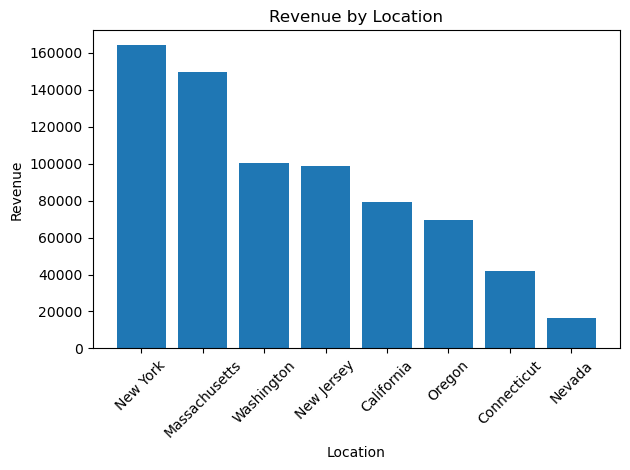

In [18]:
plt.figure()

plt.bar(
    revenue_by_location["location"],
    revenue_by_location["total_sale_amount"]
)

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [17]:
output_file = "sales_analysis_report.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    revenue_by_location.to_excel(writer, sheet_name="Revenue_by_Location", index=False)
    revenue_by_product.to_excel(writer, sheet_name="Revenue_by_Product", index=False)
    top_sales_reps.to_excel(writer, sheet_name="Top_Sales_Reps", index=False)

print("Excel report generated successfully.")

Excel report generated successfully.


## Conclusion

This project demonstrates how Python can automate the processing and analysis of logistics data stored in Excel files.

Using pandas and Python automation, the workflow performs the following steps:

- Cleans and standardizes raw datasets
- Analyzes sales performance across locations, regions, and products
- Identifies top-performing sales representatives
- Generates visual insights through charts
- Exports automated Excel reports for business use

Such automation can help logistics and operations teams reduce manual reporting work and quickly identify key business trends.